## Extrae de internet la base de datos “Amazon.xlsx” de la siguiente liga y agregala a un DataFrame en Python.
## El archivo “Amazon.xlsx” contiene los promedios de evaluación de 100 personas que adquirieron los mismos productos o muy similares en la tienda AMAZON.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# os.getcwd()
# os.chdir('C:\\Users\\saulim\\Documents\\Python Proyectos\\Jupyter notebook\\4- Aprendizaje de máquina no supervisado')

In [7]:
Amazon = pd.read_excel("Amazon.xlsx")
Amazon.head()

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43


In [8]:
Amazon.rename(columns={"Unnamed: 0": "Nombres"}, inplace=True)
Amazon_Info = Amazon.iloc[:,1:]
Amazon_Names = Amazon[["Nombres"]]
Amazon_Info
#Amazon.set_index('Nombres', inplace=True)
#Amazon

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,205,3,345,235,24,23,26,21,17
1,9,15,315,33,25,4,42,215,28
2,17,26,285,3,43,27,41,26,33
3,135,5,355,295,18,23,39,195,17
4,3,45,48,39,34,46,225,34,43
...,...,...,...,...,...,...,...,...,...
95,3,8,32,25,7,21,42,17,1
96,305,25,46,24,33,28,355,26,45
97,1,14,26,25,24,27,42,185,23
98,155,11,335,34,26,29,42,215,27


## Con base en los resultados de su análisis,
¿qué productos recomendaría a Salomé?

¿Qué productos recomendaría a Stephanía?

¿Qué productos recomendaría a Lydia?

La respuesta debe estar reflejada en función de otros clientes.

Por ejemplo, “Recomendaría a Salomé los mismos productos que compró XXXXX”. Dé nombres de clientes en cada caso. Expliqué claramente sus conclusione

In [16]:
from sklearn. preprocessing import normalize
Amazon_scaled = normalize(Amazon_Info)
Amazon_scaled

array([[0.43826336, 0.00641361, 0.73756517, 0.50239946, 0.05130888,
        0.04917101, 0.05558462, 0.04489527, 0.03634379],
       [0.02323527, 0.03872544, 0.81323434, 0.08519598, 0.06454241,
        0.01032679, 0.10843125, 0.55506471, 0.0722875 ],
       [0.05723452, 0.08753514, 0.95951982, 0.01010021, 0.14476966,
        0.09090188, 0.13803618, 0.08753514, 0.11110229],
       [0.25885639, 0.00958727, 0.68069644, 0.56564916, 0.03451419,
        0.04410146, 0.07478074, 0.37390368, 0.03259673],
       [0.01197502, 0.17962533, 0.19160036, 0.15567529, 0.13571692,
        0.18361701, 0.89812667, 0.13571692, 0.17164198],
       [0.14494006, 0.251738  , 0.60264551, 0.03661644, 0.03966781,
        0.02898801, 0.73995715, 0.03356507, 0.00457705],
       [0.04755854, 0.02481315, 0.98218723, 0.06823617, 0.07237169,
        0.09304932, 0.07857498, 0.05996511, 0.06410064],
       [0.13323393, 0.04304481, 0.06354234, 0.52268696, 0.05739308,
        0.04509456, 0.70716471, 0.44069685, 0.05944283],


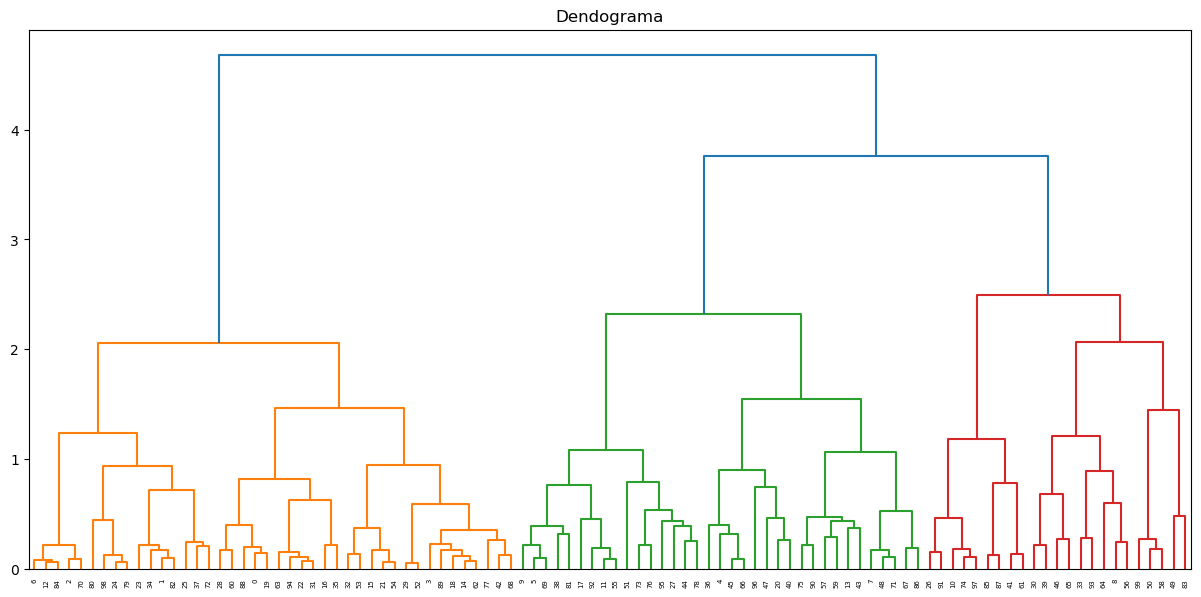

In [17]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(15,7))
plt.title("Dendograma")
dend = shc.dendrogram(shc.linkage(Amazon_scaled, method = "ward"))

In [19]:
colores_unicos = set(dend["color_list"])
N_grupos = len(colores_unicos) - 1

In [22]:
# Analisis grafico con PCA
campos = Amazon_scaled
from sklearn import decomposition
pca = decomposition.PCA(n_components = 2)
pca.fit(campos)
campos = pca.transform(campos)
campos

array([[ 0.39993219, -0.06035374],
       [ 0.40829583,  0.06402268],
       [ 0.49703182,  0.35955286],
       [ 0.33996675, -0.18434501],
       [-0.58207751,  0.38797653],
       [-0.1723403 ,  0.52962573],
       [ 0.56528441,  0.33770585],
       [-0.5335887 , -0.06994712],
       [-0.09981604, -0.47165743],
       [-0.22195207,  0.56503313],
       [-0.08274005, -0.39712712],
       [ 0.00143465,  0.48936583],
       [ 0.57292039,  0.35927774],
       [-0.51350639, -0.01301312],
       [ 0.35272162, -0.20639728],
       [ 0.4688626 , -0.0168001 ],
       [ 0.25142488, -0.04599019],
       [ 0.05456876,  0.22302796],
       [ 0.36123131, -0.20553368],
       [ 0.41087067, -0.02173183],
       [-0.54207892,  0.03308916],
       [ 0.5138909 ,  0.0900875 ],
       [ 0.4284552 ,  0.0601418 ],
       [ 0.42320562,  0.09945498],
       [ 0.42610215, -0.06318626],
       [ 0.10615885,  0.20376697],
       [-0.19058214, -0.3966612 ],
       [ 0.096838  ,  0.33104612],
       [ 0.51505714,

In [26]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters= N_grupos, metric = "euclidean", linkage = "ward")
Conjuntos = cluster.fit_predict(Amazon_scaled)

DataF = pd.DataFrame(Conjuntos, columns=["Grupos-Cluster"])
DataF

,Grupos-Cluster
0,1
1,1
2,1
3,1
4,2
...,...
95,2
96,2
97,0
98,1


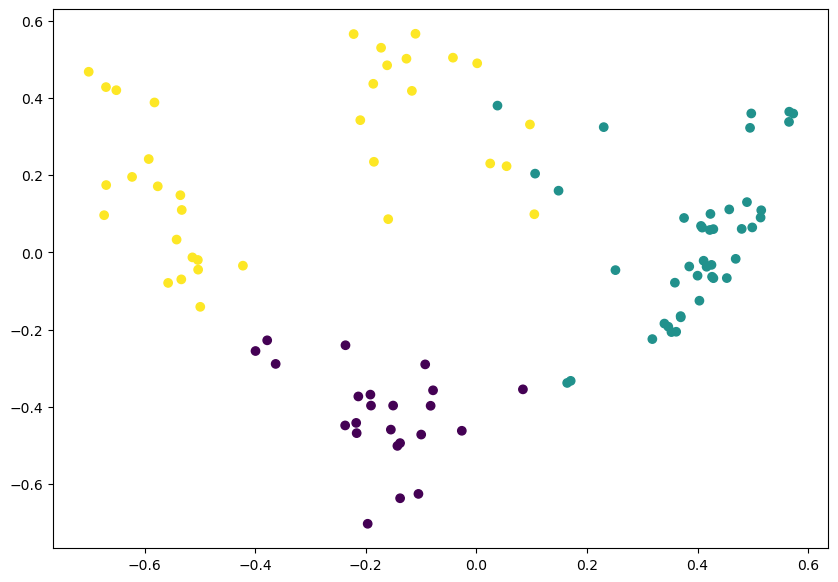

In [28]:
plt.figure(figsize=(10,7))
plt.scatter(campos[:,0], campos[:,1], c = cluster.labels_)

In [30]:
dataframe2 = pd.concat([Amazon_Names, Amazon_Info, DataF], axis = 1, join = "outer")
dataframe2.set_index('Nombres', inplace=True)
dataframe2

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,Grupos-Cluster
Nombres,,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17,1
Anna,9,15,315,33,25,4,42,215,28,1
Bernard,17,26,285,3,43,27,41,26,33,1
Edward,135,5,355,295,18,23,39,195,17,1
Emilia,3,45,48,39,34,46,225,34,43,2
...,...,...,...,...,...,...,...,...,...,...
Teofan,3,8,32,25,7,21,42,17,1,2
Teofil,305,25,46,24,33,28,355,26,45,2
Teofila,1,14,26,25,24,27,42,185,23,0


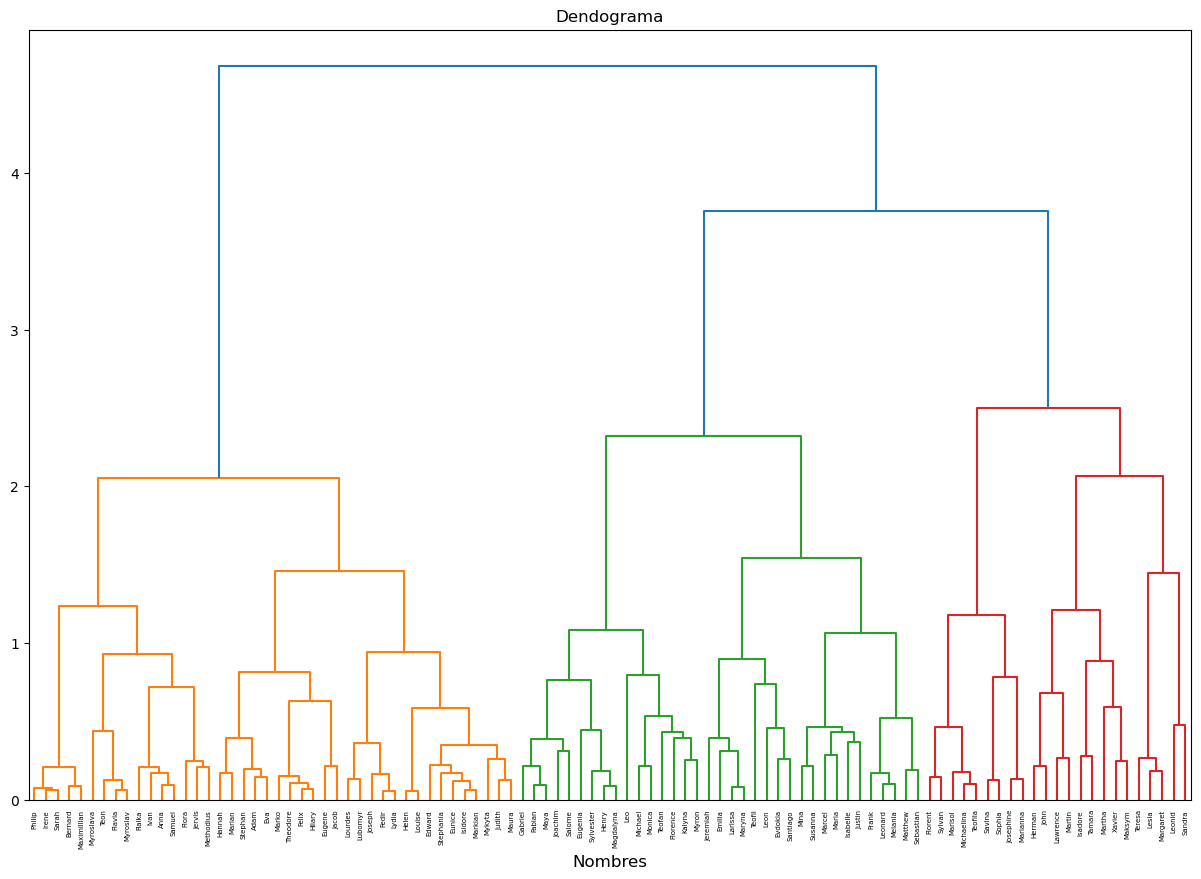

In [33]:
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(15,10))
plt.title("Dendograma")
plt.xlabel('Nombres', fontsize=12)
dend = shc.dendrogram(shc.linkage(Amazon_scaled, method = "ward"), labels = list(Amazon_Names["Nombres"]))
plt.savefig('Dendogram_Names.png', dpi=300, bbox_inches='tight')

### ¿Qué productos recomendaría a Salomé?

In [36]:
dataframe2.loc[["Salome", "Joachim"]]

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,Grupos-Cluster
Nombres,,,,,,,,,,
Salome,17,23,275,41,4,44,315,28,32,2
Joachim,0,105,345,27,11,26,445,195,14,2


In [38]:
pd.DataFrame(Amazon_scaled).iloc[[38, 81]]

,0,1,2,3,4,5,6,7,8
38,0.000000,0.173129,0.568853,0.044519,0.018137,0.042870,0.733738,0.321526,0.023084
81,0.039947,0.054045,0.646194,0.096342,0.009399,0.103391,0.740185,0.065794,0.075193


De acuerdo con el dendograma los dos conjuntos de datos más próximos entre ellos fue Salome y Joachim, esto dado que al estandarizar los dato tienen una proximidad bastante alta.

### ¿Qué productos recomendaría a Stephanía?

In [42]:
dataframe2.loc[["Stephania", "Eunice", "Isidore", "Markian"]]

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,Grupos-Cluster
Nombres,,,,,,,,,,
Stephania,215,125,465,315,34,4,37,305,45,1
Eunice,265,7,485,305,33,39,34,295,39,1
Isidore,235,65,495,335,3,26,34,295,39,1
Markian,205,55,465,275,25,27,37,265,32,1


In [44]:
pd.DataFrame(Amazon_scaled).iloc[[89, 18, 14, 62]]

,0,1,2,3,4,5,6,7,8
89,0.311991,0.181390,0.674770,0.457102,0.049338,0.005804,0.053691,0.442591,0.065300
18,0.378249,0.009991,0.692267,0.435343,0.047103,0.055667,0.048530,0.421070,0.055667
14,0.330010,0.091279,0.695127,0.470439,0.004213,0.036512,0.047746,0.414267,0.054768
62,0.319816,0.085804,0.725437,0.429022,0.039002,0.042122,0.057723,0.413421,0.049923


Stephani se le recomendaría comprar los mismos productos que compro el grupo de Eunice, Isidore y Markian, esto dado que de acuerdo a la normalización en el Dendograma cuando las tres personas anteriores forman un conjunto entonces Stephani tendría la recomendación de los mismos productos, aunque Eunice sería la de mayor prioridad dado que el grupo más pequeño es de Isidore y Markian.

### ¿Qué productos recomendaría a Lydia?

In [48]:
dataframe2.loc[["Lydia", "Fedir"]]

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,Grupos-Cluster
Nombres,,,,,,,,,,
Lydia,19,4,435,145,16,21,28,185,24,1
Fedir,17,2,415,125,12,17,26,165,2,1


In [50]:
pd.DataFrame(Amazon_scaled).iloc[[51, 24]]

,0,1,2,3,4,5,6,7,8
51,0.136150,0.251354,0.429396,0.261827,0.377031,0.261827,0.471288,0.272300,0.397977
24,0.452067,0.012410,0.771172,0.042547,0.058503,0.046093,0.033683,0.434338,0.060276


Lydia está en un conjunto de 2 personas en el dendograma lo que hace que se recomiende que compre el mismo producto que Fedir, y en este caso en particular tienen varios valores similares en múltiples grupos/conjuntos.

## Hypervinculo del grafico generado
https://drive.google.com/file/d/1gH5yf16y1cb7rUYYaZpHyHli9h2ngMCu/view?usp=sharing

Link de drive para ver la gráfica generada con mayor calidad (no sé cuánto tiempo lo deje ahí por lo que recomiendo descargarlo)